In [1]:
from __future__ import annotations

import numpy as np
import torch
import matplotlib.pyplot as plt
from pete import pset
from sa_preisach.models import EncoderDecoderPreisachNN
from sa_preisach.data import PreisachDataModule

from sa_preisach.callbacks import PlotHysteresisCallback

pset.setup(fig_dir=".", autosave=False)


In [2]:
# Custom mesh function

class DefaultMeshSizeFunction:
    def __init__(self, scale: float = 0.2, offset: float = 0.05):
        self.scale = scale
        self.offset = offset

    def __call__(self, x: np.ndarray, y: np.ndarray, mesh_scale: float) -> np.ndarray:
        return mesh_scale * (self.scale * np.abs(x - y) + self.offset)

In [23]:
module = EncoderDecoderPreisachNN(
    hidden_dim=32,
    num_encoder_layers=2,  # LSTM layers
    num_layers=2,  # MLP layers
    # mesh_density_function=DefaultMeshSizeFunction(scale=0.1, offset=0.05),
    mesh_density_function="default",
    mesh_scale=0.1,
    mesh_perturbation_std=0.05,
)

model = module.model

In [24]:
mesh = model.base_mesh

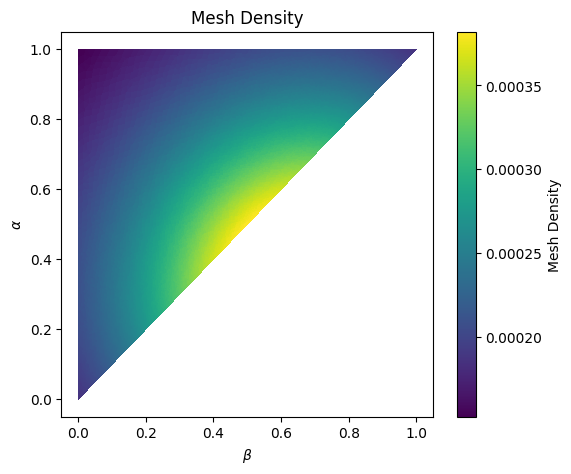

In [26]:
beta = mesh[:, 0]
alpha = mesh[:, 1]

with torch.no_grad():
    density = model.density_from_mesh(
        model.get_batched_mesh_coords(batch_size=1)
        ).squeeze().numpy()
    
# hack density to be closeness of points, ignore density, use mesh coordinates to compute density as closeness of points
density = 1 / (np.sqrt((beta[:, None] - alpha[None, :]) ** 2 + (alpha[:, None] - beta[None, :]) ** 2) + 1e-5).sum(axis=1)

with pset.subplots(name="mesh", figsize=(6, 5)) as (fig, ax):
    sc = ax.tripcolor(beta, alpha, density, cmap="viridis")

    ax.set_xlabel("$\\beta$")
    ax.set_ylabel("$\\alpha$")
    ax.set_title("Mesh Density")
    plt.colorbar(sc, label="Mesh Density")